# Median market capitalization by sector

Aggregate data is data combined from several measurements. As you learned in the video, the .groupby() function is helpful in aggregating your data by a specific category.

In [16]:
import pandas as pd
xls = pd.ExcelFile('dataset/listings.xlsx')

# Extract the sheet names from xls
exchanges = xls.sheet_names

# Create an empty list: listings
listings = {}

# Import the data
for exchange in exchanges:
    listings[exchange] = pd.read_excel(
        xls, sheet_name=exchange, na_values='n/a')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3147 entries, 0 to 3146
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Stock Symbol           3147 non-null   object 
 1   Company Name           3147 non-null   object 
 2   Last Sale              3079 non-null   float64
 3   Market Capitalization  3147 non-null   float64
 4   IPO Year               1361 non-null   float64
 5   Sector                 2177 non-null   object 
 6   Industry               2177 non-null   object 
dtypes: float64(3), object(4)
memory usage: 172.2+ KB


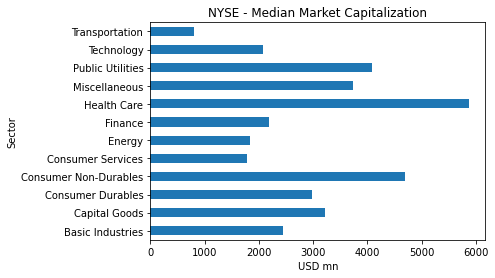

In [17]:
import matplotlib.pyplot as plt

nyse = listings["nyse"]
# Inspect NYSE data
nyse.info()

# Create market_cap_m
nyse['market_cap_m'] = nyse["Market Capitalization"].div(1e6)

# Drop market cap column
nyse = nyse.drop('Market Capitalization', axis=1)

# Group nyse by sector
mcap_by_sector = nyse.groupby("Sector")

# Calculate median
median_mcap_by_sector = mcap_by_sector.market_cap_m.median()

# Plot and show as horizontal bar chart
median_mcap_by_sector.plot(
    kind="barh", title='NYSE - Median Market Capitalization')

# Add the label
plt.xlabel('USD mn')

# Show the plot
plt.show()

# Median market capitalization by IPO year

In the last lesson of the previous chapter, you created a timeline for the number of IPOs per year for technology companies.

Let's now analyze how market capitalization has evolved for different IPO years. You can combine data from all three exchanges to get a more comprehensive view.

In [18]:
# Create the pd.ExcelFile() object
xls = pd.ExcelFile("dataset/listings.xlsx")

# Extract the sheet names from xls
exchanges = xls.sheet_names

# Create an empty list: listings
listings = []

# Import the data
for exchange in exchanges:
    listing = pd.read_excel(xls, sheet_name=exchange, na_values='n/a')
    listing['Exchange'] = exchange
    listings.append(listing)

# Concatenate the listings: listing_data
listing_data = pd.concat(listings)

# Inspect the results
listing_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6674 entries, 0 to 3146
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Stock Symbol           6674 non-null   object 
 1   Company Name           6674 non-null   object 
 2   Last Sale              6590 non-null   float64
 3   Market Capitalization  6674 non-null   float64
 4   IPO Year               2852 non-null   float64
 5   Sector                 5182 non-null   object 
 6   Industry               5182 non-null   object 
 7   Exchange               6674 non-null   object 
dtypes: float64(3), object(5)
memory usage: 469.3+ KB


<class 'pandas.core.frame.DataFrame'>
Int64Index: 6674 entries, 0 to 3146
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Stock Symbol           6674 non-null   object 
 1   Company Name           6674 non-null   object 
 2   Last Sale              6590 non-null   float64
 3   Market Capitalization  6674 non-null   float64
 4   IPO Year               2852 non-null   float64
 5   Sector                 5182 non-null   object 
 6   Industry               5182 non-null   object 
 7   Exchange               6674 non-null   object 
dtypes: float64(3), object(5)
memory usage: 469.3+ KB
     Stock Symbol                                       Company Name  \
0            XXII                            22nd Century Group, Inc   
1             FAX              Aberdeen Asia-Pacific Income Fund Inc   
2             IAF                 Aberdeen Australia Equity Fund Inc   
3              CH               

C:\Users\88016\AppData\Local\Temp/ipykernel_19188/4154037856.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  listings['IPO Year'] = listings['IPO Year'].dropna().astype(int)


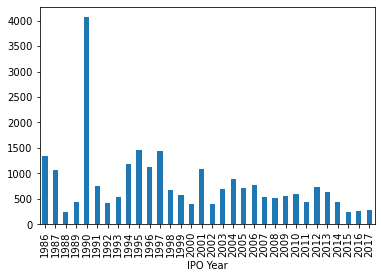

In [19]:
listings = listing_data
# Inspect listings
listings.info()

# Show listings head
print(listings.head())

# Create market_cap_m
listings['market_cap_m'] = listings["Market Capitalization"].div(1e6)

# Select companies with IPO after 1985
listings = listings[listings["IPO Year"] > 1985]

# Drop missing values and convert to integers
listings['IPO Year'] = listings['IPO Year'].dropna().astype(int)

# Calculate the median market cap by IPO Year and sort the index
ipo_by_year = listings.groupby('IPO Year').market_cap_m.median().sort_index()

# Plot results as a bar chart
ipo_by_year.plot(kind='bar')

# Show the plot
plt.show()

# All summary statistics by sector

You can apply the various summary statistics that you have learned about in the last chapter to a groupby object to obtain the result on a per-category basis. This includes the .describe() function, which provides several insights all at once!

In [31]:
import pandas as pd
xls = pd.ExcelFile('dataset/listings.xlsx')

# Extract the sheet names from xls
exchanges = xls.sheet_names

# Create an empty list: listings
listings = {}

# Import the data
for exchange in exchanges:
    listings[exchange] = pd.read_excel(
        xls, sheet_name=exchange, na_values='n/a')

c:\Users\88016\anaconda3\envs\env_py\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [23]:
nasdaq = listings["nasdaq"]
# Inspect NASDAQ data
nasdaq.info()

# Create market_cap_m
nasdaq['market_cap_m'] = nasdaq["Market Capitalization"].div(1e6)

# Drop the Market Capitalization column
nasdaq.drop('Market Capitalization', axis=1, inplace=True)

# Group nasdaq by Sector
nasdaq_by_sector = nasdaq.groupby("Sector")

# Create summary statistics by sector
summary = nasdaq_by_sector.describe()

# Print the summary
print(summary)

# Unstack
summary = summary.unstack()

# Print the summary again
print(summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3167 entries, 0 to 3166
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Stock Symbol           3167 non-null   object 
 1   Company Name           3167 non-null   object 
 2   Last Sale              3165 non-null   float64
 3   Market Capitalization  3167 non-null   float64
 4   IPO Year               1386 non-null   float64
 5   Sector                 2767 non-null   object 
 6   Industry               2767 non-null   object 
dtypes: float64(3), object(4)
memory usage: 173.3+ KB
                      Last Sale                                          \
                          count       mean         std     min      25%   
Sector                                                                    
Basic Industries           78.0  21.597679   29.009745  0.0336   2.6325   
Capital Goods             172.0  26.188681   36.596723  0.1500   4.3800 

# Company value by exchange and sector

You can generate more fine-grained summaries of your data by providing a list of columns inside .groupby() and/or applying a statistical method such as .mean() directly to one or more numerical columns.

Here, you will calculate the median market capitalization for each sector, differentiated by the exchange that the companies are listed on. You will also use .unstack() to pivot the exchange labels from the rows into the columns. It's a good idea to inspect listings in your console before starting the exercise!

In [35]:
# # Group listings by Sector and Exchange
# by_sector_exchange = listings.groupby(['Sector', 'Exchange'])

# # Calculate the median market cap
# mcap_by_sector_exchange = by_sector_exchange.market_cap_m.median()

# # Display the head of the result
# print(mcap_by_sector_exchange.head())

# # Unstack mcap_by_sector_exchange
# mcap_unstacked = mcap_by_sector_exchange.unstack()

# # Plot as a bar chart
# mcap_unstacked.plot(
#     kind="bar", title='Median Market Capitalization by Exchange')

# # Set the x label
# plt.ylabel('USD mn')

# # Show the plot
# plt.show()

# Calculate several metrics by sector and exchange

The .agg() function allows you to aggregate your data in even more ways. Providing a list of names of statistical methods calculates more than one summary statistic at once. You can provide new names for the aggregated columns using the rename method, which takes a dictionary argument where the keys are the names of the metrics you computes and the values are your desired new names.

In [36]:
# # Create market_cap_m
# listings['market_cap_m'] = listings["Market Capitalization"].div(1e6)

# # Group listing by both Sector and Exchange
# by_sector_exchange = listings.groupby(['Sector', 'Exchange'])

# # Subset market_cap_m of by_sector_exchange
# bse_mcm = by_sector_exchange["market_cap_m"]

# # Calculate mean, median, and std in summary
# summary = bse_mcm.agg(['mean', 'median', 'std']).rename(
#     columns={'mean': "Average", 'median': "Median", 'std': "Standard Deviation"})

# # Print the summary
# print(summary)

# Plot IPO timeline for all exchanges using countplot()

To create a basic visualization of the number of observations per category in a dataset, the seaborn countplot() function is usually the way to go:

`seaborn.countplot(x=None, hue=None, data=None, ...)`

In [38]:
# import seaborn as sns
# # Select IPOs after 2000
# listings = listings[listings["IPO Year"] > 2000]

# # Convert IPO Year to integer
# listings['IPO Year'] = listings['IPO Year'].astype(int)

# # Create a countplot
# sns.countplot(x='IPO Year', hue='Exchange', data=listings)

# # Rotate xticks and show result
# plt.xticks(rotation=45)

# # Show the plot
# plt.show()

# Global median per capita income over time

The seaborn barplot() function shows point estimates and confidence intervals as rectangular bars; the default function displays the mean, but it can also represent another summary statistic if you pass a particular numpy function to its estimator parameter:

`eaborn.barplot(x=None, y=None, data=None, estimator=<function mean>, ...)`

In [39]:
# # Inspect the data
# income_trend.info()

# # Create barplot
# sns.barplot(x='Year', y='Income per Capita', data=income_trend)

# # Rotate xticks
# plt.xticks(rotation=45)

# # Show the plot
# plt.show()

# # Close the plot
# plt.close()

# # Create second barplot
# sns.barplot(x='Year', y='Income per Capita',
#             data=income_trend, estimator=np.median)

# # Rotate xticks
# plt.xticks(rotation=45)

# # Show the plot
# plt.show()

# Calculate several metrics by sector and IPO year

The seaborn pointplot() function facilitates the comparison of summary statistics of a numerical variable for different levels of categorical variables:

`seaborn.pointplot(x=None, y=None, hue=None, data=None, ...)`

In [40]:
# # Import the seaborn library as sns
# import seaborn as sns

# # Exclude IPOs before 2000 and from the 'amex'
# listings = listings[(listings['IPO Year'] > 2000) &
#                     (listings.Exchange != 'amex')]

# # Convert IPO Year to integer
# listings['IPO Year'] = listings['IPO Year'].astype(int)

# # Create market_cap_m
# listings['market_cap_m'] = listings['Market Capitalization'].div(1e6)

# # Exclude outliers
# listings = listings[listings.market_cap_m <
#                     listings.market_cap_m.quantile(.95)]

# # Create the pointplot
# sns.pointplot(x='IPO Year', y='market_cap_m', hue='Exchange', data=listings)

# # Rotate xticks
# plt.xticks(rotation=45)

# # Show the plot
# plt.show()

# Inflation trends in China, India, and the US

The seaborn package includes functions that allow you to visualize the distribution of levels of categorical variables.

In [41]:
# # Inspect the inflation data
# inflation.info()

# # Create inflation_by_country
# inflation_by_country = inflation.groupby("Country")

# # Iterate over inflation_by_country and plot the inflation time series per country
# for country, data in inflation_by_country:
#     # Plot the data
#     data.plot(title=country)
#     # Show the plot
#     plt.show()

# Distribution of inflation rates in China, India, and the US

As you saw in the video, the boxplot() function displays key quantiles of a distribution with respect to categories, where y represents a quantitative variable, and x a categorical variable. In statistics, this kind of distribution is known as a box-and-whisker plot.

A complement to a box plot is a swarmplot(), which draws a categorical scatterplot that displays all categorical observations without overlapping; it takes similar arguments to boxplot():
```
seaborn.boxplot(x=None, y=None, data=None, ...)
seaborn.swarmplot(x=None, y=None, data=None, ...)
```

In [42]:
# # Create boxplot
# sns.boxplot(x='Country', y='Inflation', data=inflation)

# # Show the plot
# plt.show()

# # Close the plot
# plt.close()

# # Create swarmplot
# sns.swarmplot(x='Country', y='Inflation', data=inflation)

# # Show the plot
# plt.show()